# Fixed-Bias Heuristic Test For 3 gNodeBs

This notebook tests the lower heuristic controllers without training and without the upper PPO agent. There is one heuristic lower agent per gNodeB. You choose fixed 3x3 bias matrices, run them in the 3-gNB environment, and observe how load, UE counts, handovers, and A3 offsets change.

Rows are gNodeBs `0, 1, 2`; columns are slices `eMBB, URLLC, mMTC`. Negative bias encourages offload from that gNB/slice. Positive bias encourages retention.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "global_ppo_3gnb_env.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from global_ppo_3gnb_env import DEFAULT_GNB_CONFIGS_3, GLOBAL_SNAPSHOT_SCENARIOS, GlobalPPO3GNBEnv, SLICE_TYPES

plt.rcParams.update({"figure.dpi": 125, "axes.grid": True, "grid.alpha": 0.22})
np.set_printoptions(precision=3, suppress=True)

GNB_IDS = [0, 1, 2]
SLICE_COLORS = {"eMBB": "#2563eb", "URLLC": "#dc2626", "mMTC": "#16a34a"}
GNB_POS = {int(cfg["id"]): (float(cfg["x"]), float(cfg["y"]), float(cfg["coverage_radius"])) for cfg in DEFAULT_GNB_CONFIGS_3}

print(f"Project root: {PROJECT_ROOT}")
print("Slices:", SLICE_TYPES)
print("Available scenarios:", list(GLOBAL_SNAPSHOT_SCENARIOS))

Project root: /home/oussama/Desktop/RL_juin
Slices: ('eMBB', 'URLLC', 'mMTC')
Available scenarios: ['embb_g0_offload', 'urllc_g1_offload', 'mmtc_g2_offload', 'embb_g0_urllc_g1_conflict', 'mmtc_g2_embb_g1_conflict', 'all_offload_balancing', 'multi_slice_multi_gnb_congestion', 'all_neutral']


## Scenario And Fixed Bias Matrices

Edit `SCENARIO_NAME`, `N_WINDOWS`, or the matrices in `BIAS_MATRICES` to run your own tests.

In [2]:
SCENARIO_NAME = "embb_g0_offload"
USE_CUSTOM_TARGET_MATRIX = True
CUSTOM_TARGET_MATRIX = np.array([
    [0.80, 0.20, 0.20],  # gNB 0 has high eMBB load
    [0.20, 0.20, 0.20],  # gNB 1 is light
    [0.20, 0.20, 0.20],  # gNB 2 is light
], dtype=float)
N_WINDOWS = 12
LOCAL_STEPS_PER_GLOBAL = 10
MAX_HANDOVERS_PER_LOCAL_STEP = 1

# 5 eMBB + 5 URLLC + 5 mMTC = 15 UEs total.
# If you really want 10 total UEs, edit these rows so all values sum to 10.
USE_CUSTOM_UE_COUNTS = True
CUSTOM_UE_COUNTS = pd.DataFrame(
    [
        [3, 1, 1],  # gNB 0: eMBB, URLLC, mMTC
        [1, 2, 2],  # gNB 1
        [1, 2, 2],  # gNB 2
    ],
    index=[f"gNB {g}" for g in GNB_IDS],
    columns=SLICE_TYPES,
)

BIAS_MATRICES = {
    "zero_bias_baseline": np.array([
        [0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0],
        [0.0, 0.0, 0.0],
    ], dtype=float),
    "offload_g0_embb": np.array([
        [-1.0, 0.0, 0.0],  # push eMBB away from gNB 0
        [ 1.0, 0.0, 0.0],  # retain/accept eMBB at gNB 1
        [ 1.0, 0.0, 0.0],  # retain/accept eMBB at gNB 2
    ], dtype=float),
    "offload_g0_all_slices": np.array([
        [-1.0, -1.0, -1.0],
        [ 1.0,  1.0,  1.0],
        [ 1.0,  1.0,  1.0],
    ], dtype=float),
    "manual_balance_example": np.array([
        [-1.0,  0.0,  0.0],
        [ 1.0,  0.0,  0.0],
        [ 1.0,  0.0,  0.0],
    ], dtype=float),
}

target_matrix = CUSTOM_TARGET_MATRIX.copy() if USE_CUSTOM_TARGET_MATRIX else np.asarray(GLOBAL_SNAPSHOT_SCENARIOS[SCENARIO_NAME], dtype=float)
display(pd.DataFrame(target_matrix, index=[f"gNB {g}" for g in GNB_IDS], columns=SLICE_TYPES).style.set_caption("Target load matrix"))
display(CUSTOM_UE_COUNTS.style.set_caption(f"Custom UE counts, total={int(CUSTOM_UE_COUNTS.to_numpy().sum())}"))

,eMBB,URLLC,mMTC
gNB 0,0.800000,0.200000,0.200000
gNB 1,0.200000,0.200000,0.200000
gNB 2,0.200000,0.200000,0.200000


,eMBB,URLLC,mMTC
gNB 0,3,1,1
gNB 1,1,2,2
gNB 2,1,2,2


## Plot Helpers

In [3]:
def heatmap(ax, matrix, title, cmap="viridis", vmin=0.0, vmax=1.0):
    matrix = np.asarray(matrix, dtype=float)
    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(SLICE_TYPES)), SLICE_TYPES)
    ax.set_yticks(range(len(GNB_IDS)), [f"gNB {g}" for g in GNB_IDS])
    ax.set_title(title)
    for r in range(matrix.shape[0]):
        for c in range(matrix.shape[1]):
            ax.text(c, r, f"{matrix[r, c]:.2f}", ha="center", va="center", color="white", fontsize=8, fontweight="bold")
    return im

def draw_base_topology(ax):
    for gnb_id, (x, y, radius) in GNB_POS.items():
        ax.add_patch(Circle((x, y), radius, fill=False, linestyle="--", linewidth=1.2, alpha=0.35, color="#475569"))
        ax.scatter([x], [y], s=260, marker="^", color="#111827", zorder=5)
        ax.text(x, y + 28, f"gNB {gnb_id}", ha="center", va="bottom", fontweight="bold")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

def draw_topology_load(ax, matrix, title):
    offsets = {"eMBB": (-42, -30), "URLLC": (42, -30), "mMTC": (0, 48)}
    draw_base_topology(ax)
    for gnb_id, (x, y, _radius) in GNB_POS.items():
        for s_idx, slice_type in enumerate(SLICE_TYPES):
            value = float(matrix[gnb_id, s_idx])
            dx, dy = offsets[slice_type]
            ax.scatter([x + dx], [y + dy], s=260 + 1250 * value, color=SLICE_COLORS[slice_type], alpha=0.76, edgecolor="white", linewidth=1.1, zorder=6)
            ax.text(x + dx, y + dy, f"{value:.2f}", color="white", ha="center", va="center", fontsize=8, fontweight="bold", zorder=7)
    handles = [plt.Line2D([0], [0], marker="o", color="w", label=s, markerfacecolor=SLICE_COLORS[s], markersize=9) for s in SLICE_TYPES]
    ax.legend(handles=handles, loc="upper right")
    ax.set_title(title)

def matrix_df(matrix):
    return pd.DataFrame(np.asarray(matrix, dtype=float), index=[f"gNB {g}" for g in GNB_IDS], columns=SLICE_TYPES)

## Environment Helpers

`env.step(fixed_bias.reshape(-1))` uses the 3 lower heuristic agents. It is the same path the upper PPO uses, except the action is your fixed matrix.

`zero_bias_baseline` means no upper pressure, not no control. With bias `0`, the lower heuristic still uses load difference and UE-count pressure, so handovers and load changes can still happen.

In [4]:
def make_env(seed=7):
    return GlobalPPO3GNBEnv(
        seed=seed,
        n_gnbs=3,
        include_ue_counts=True,
        use_sumo_mobility=False,
        local_steps_per_global=LOCAL_STEPS_PER_GLOBAL,
        global_steps_per_episode=N_WINDOWS,
        scenario_mode="snapshot",
        snapshot_scenario=SCENARIO_NAME,
        terminal_reward_only=False,
        use_progress_reward=False,
        max_handovers_per_local_step=MAX_HANDOVERS_PER_LOCAL_STEP,
        action_direction_reward_weight=0.0,
        snapshot_block_episodes=10,
        light_load_ues=1,
        medium_load_ues=2,
        high_load_ues=3,
    )

def reset_scenario(env):
    obs, info = env.reset()
    if not USE_CUSTOM_UE_COUNTS:
        return obs, info

    counts = CUSTOM_UE_COUNTS.to_numpy(dtype=int)
    env.base_env.clear_ues(reset_ids=True)
    env._active_scenario = f"{SCENARIO_NAME}_custom_ue_counts"
    env._active_target_load_matrix = target_matrix.copy()
    for gnb_id in GNB_IDS:
        for s_idx, slice_type in enumerate(SLICE_TYPES):
            target = float(target_matrix[gnb_id, s_idx])
            for ue_idx in range(int(counts[gnb_id, s_idx])):
                x, y = env._sample_ue_position(gnb_id, slice_type, target, ue_idx)
                ue_id = env.base_env.add_ue(x=x, y=y, vx=0.0, vy=0.0, slice_type=slice_type)
                env._force_attach(ue_id, gnb_id)
            env._set_slice_prb_load(gnb_id, slice_type, target)
    env.base_env._invalidate_metric_caches()
    obs = env._get_observation()
    error = env._target_load_error()
    info = env._build_info(reward=0.0, instant_rewards=[], handovers=0, start_imbalance=error, end_imbalance=error)
    return obs, info

def collect_offsets(env, bias_matrix):
    ue_counts = env._ue_count_dict()
    slice_loads = env._slice_load_dict()
    kmax = env._kmax_by_slice()
    rows = []
    for gnb_id, agent in env.lower_agents.items():
        bias_row = {s: float(bias_matrix[gnb_id, s_idx]) for s_idx, s in enumerate(SLICE_TYPES)}
        offsets = agent.compute_offsets(
            bias_row=bias_row,
            ue_counts=ue_counts,
            kmax=kmax,
            slice_loads=slice_loads,
            handover_failure_ratios={},
            ping_pong_ratios={},
        )
        for (src, dst, slice_type), value in offsets.items():
            rows.append({
                "from_gnb": src,
                "to_gnb": dst,
                "slice": slice_type,
                "bias": bias_row[slice_type],
                "serving_load": float(slice_loads[(src, slice_type)]),
                "neighbor_load": float(slice_loads[(dst, slice_type)]),
                "proto_offset_db": float(value["proto_offset_db"]),
                "applied_offset_db": float(value["applied_offset_db"]),
            })
    return pd.DataFrame(rows).sort_values(["from_gnb", "slice", "to_gnb"])

def rollout_fixed_bias(name, bias_matrix, seed=7):
    env = make_env(seed=seed)
    history = []
    offset_frames = []
    try:
        obs, info = reset_scenario(env)
        initial_load = np.asarray(info["load_matrix"], dtype=float)
        initial_ue_count = np.asarray(info["ue_count_matrix"], dtype=float)
        balance_target = np.asarray(info["balance_target_matrix"], dtype=float)
        target_load = np.asarray(info["target_load_matrix"], dtype=float)

        for window in range(N_WINDOWS):
            before_load = env._load_matrix()
            before_ue_count = np.asarray([[env.base_env.get_slice_ue_count(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)
            before_error = env._target_load_error(before_load)
            offsets = collect_offsets(env, bias_matrix)
            offsets.insert(0, "window", window)
            offsets.insert(0, "test", name)
            offset_frames.append(offsets)

            obs, reward, terminated, truncated, info = env.step(bias_matrix.reshape(-1))
            after_load = np.asarray(info["load_matrix"], dtype=float)
            after_ue_count = np.asarray(info["ue_count_matrix"], dtype=float)
            history.append({
                "test": name,
                "window": window,
                "reward": float(reward),
                "target_error_before": float(before_error),
                "target_error_after": float(info["target_load_error"]),
                "target_error_delta": float(before_error - float(info["target_load_error"])),
                "load_variance": float(info["load_variance"]),
                "sla_count": float(info["sla_count"]),
                "handover_count": int(info["handover_count"]),
                "mean_abs_load_change": float(np.mean(np.abs(after_load - before_load))),
                "mean_abs_ue_count_change": float(np.mean(np.abs(after_ue_count - before_ue_count))),
            })
            if terminated or truncated:
                break

        final_load = env._load_matrix()
        final_ue_count = np.asarray(info["ue_count_matrix"], dtype=float)
        ue_rows = []
        for ue in env.base_env.get_all_ues():
            ue_rows.append({
                "test": name,
                "ue_id": int(ue.id),
                "slice": str(getattr(ue, "slice_type", "eMBB")),
                "serving_gnb": int(ue.serving_gnb) if ue.serving_gnb is not None else -1,
                "x": float(ue.x),
                "y": float(ue.y),
            })
    finally:
        env.close()

    return {
        "name": name,
        "bias_matrix": np.asarray(bias_matrix, dtype=float),
        "target_load": target_load,
        "balance_target": balance_target,
        "initial_load": initial_load,
        "final_load": final_load,
        "initial_ue_count": initial_ue_count,
        "final_ue_count": final_ue_count,
        "history": pd.DataFrame(history),
        "offsets": pd.concat(offset_frames, ignore_index=True) if offset_frames else pd.DataFrame(),
        "ues": pd.DataFrame(ue_rows),
    }

## True Radio-Only Baseline

This advances the base simulator directly without calling the heuristic handover controller. UE positions remain fixed in both tests, but traffic queues and radio scheduling can still change slice load.

,window,target_error_before,target_error_after,mean_abs_load_change,handover_count
0,0,0.026667,0.142912,0.319865,0
1,1,0.142912,0.142259,0.033670,0
2,2,0.142259,0.138994,0.033670,0
3,3,0.138994,0.137361,0.033670,0
4,4,0.137361,0.159074,0.107744,0
5,5,0.159074,0.206314,0.164983,0
6,6,0.206314,0.147809,0.138047,0
7,7,0.147809,0.270205,0.175084,0
8,8,0.270205,0.142912,0.276094,0
9,9,0.142912,0.146667,0.013468,0


UE positions changed: False
UE serving gNB changed: False


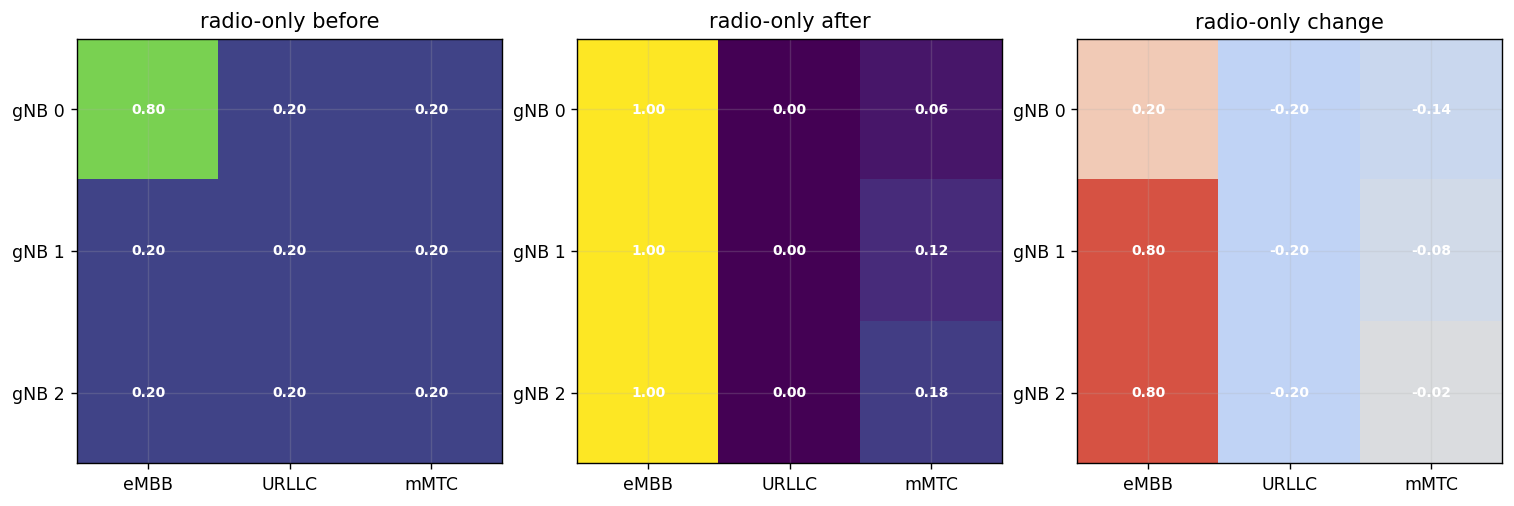

In [5]:
def radio_only_rollout(seed=7, windows=N_WINDOWS):
    env = make_env(seed=seed)
    rows = []
    try:
        obs, info = reset_scenario(env)
        initial_load = np.asarray(info["load_matrix"], dtype=float)
        initial_ue_count = np.asarray(info["ue_count_matrix"], dtype=float)
        initial_positions = pd.DataFrame([
            {"ue_id": int(ue.id), "x": float(ue.x), "y": float(ue.y), "serving_gnb": int(ue.serving_gnb)}
            for ue in env.base_env.get_all_ues()
        ]).sort_values("ue_id")

        for window in range(windows):
            before_load = env._load_matrix()
            for _ in range(LOCAL_STEPS_PER_GLOBAL):
                env.base_env.step(0)
            env.base_env._invalidate_metric_caches()
            after_load = env._load_matrix()
            rows.append({
                "window": window,
                "target_error_before": float(env._target_load_error(before_load)),
                "target_error_after": float(env._target_load_error(after_load)),
                "mean_abs_load_change": float(np.mean(np.abs(after_load - before_load))),
                "handover_count": 0,
            })

        final_load = env._load_matrix()
        final_ue_count = np.asarray([[env.base_env.get_slice_ue_count(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)
        final_positions = pd.DataFrame([
            {"ue_id": int(ue.id), "x": float(ue.x), "y": float(ue.y), "serving_gnb": int(ue.serving_gnb)}
            for ue in env.base_env.get_all_ues()
        ]).sort_values("ue_id")
    finally:
        env.close()

    pos_delta = initial_positions.merge(final_positions, on="ue_id", suffixes=("_before", "_after"))
    pos_delta["position_changed"] = (pos_delta["x_before"] != pos_delta["x_after"]) | (pos_delta["y_before"] != pos_delta["y_after"])
    pos_delta["serving_changed"] = pos_delta["serving_gnb_before"] != pos_delta["serving_gnb_after"]
    return {
        "history": pd.DataFrame(rows),
        "initial_load": initial_load,
        "final_load": final_load,
        "initial_ue_count": initial_ue_count,
        "final_ue_count": final_ue_count,
        "ue_position_check": pos_delta,
    }

radio_only = radio_only_rollout()
display(radio_only["history"])
print("UE positions changed:", bool(radio_only["ue_position_check"]["position_changed"].any()))
print("UE serving gNB changed:", bool(radio_only["ue_position_check"]["serving_changed"].any()))

fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
heatmap(axes[0], radio_only["initial_load"], "radio-only before", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[1], radio_only["final_load"], "radio-only after", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[2], radio_only["final_load"] - radio_only["initial_load"], "radio-only change", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

## Run All Fixed-Bias Tests

In [6]:
results = {name: rollout_fixed_bias(name, bias) for name, bias in BIAS_MATRICES.items()}

summary_rows = []
for name, result in results.items():
    hist = result["history"]
    summary_rows.append({
        "test": name,
        "initial_error": float(hist["target_error_before"].iloc[0]),
        "final_error": float(hist["target_error_after"].iloc[-1]),
        "error_improvement": float(hist["target_error_before"].iloc[0] - hist["target_error_after"].iloc[-1]),
        "total_handovers": int(hist["handover_count"].sum()),
        "mean_sla_count": float(hist["sla_count"].mean()),
        "mean_abs_load_change_per_window": float(hist["mean_abs_load_change"].mean()),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("error_improvement", ascending=False)
display(summary_df)
display(pd.concat([r["history"] for r in results.values()], ignore_index=True).head(20))

,test,initial_error,final_error,error_improvement,total_handovers,mean_sla_count,mean_abs_load_change_per_window
0,zero_bias_baseline,0.026667,0.136872,-0.110205,120,0.166667,0.140988
1,offload_g0_embb,0.026667,0.173807,-0.147140,3,0.250000,0.137318
2,offload_g0_all_slices,0.026667,0.176419,-0.149752,3,0.083333,0.178058
3,manual_balance_example,0.026667,0.246677,-0.220010,3,0.250000,0.155331


,test,window,reward,target_error_before,target_error_after,target_error_delta,load_variance,sla_count,handover_count,mean_abs_load_change,mean_abs_ue_count_change
0,zero_bias_baseline,0,-1.190385,0.026667,0.203804,-0.177137,0.169779,0.0,10,0.379125,0.444444
1,zero_bias_baseline,1,-0.415371,0.203804,0.144381,0.059423,0.000816,0.0,10,0.141414,0.000000
2,zero_bias_baseline,2,-0.321659,0.144381,0.151238,-0.006856,0.052240,0.0,10,0.060606,0.000000
3,zero_bias_baseline,3,-0.582841,0.151238,0.192162,-0.040924,0.200544,1.0,10,0.137849,0.000000
4,zero_bias_baseline,4,-0.941482,0.192162,0.214905,-0.022743,0.190185,0.0,10,0.090711,0.000000
5,zero_bias_baseline,5,-0.531203,0.214905,0.234494,-0.019590,0.326497,0.0,10,0.087542,0.000000
6,zero_bias_baseline,6,-0.410175,0.234494,0.144381,0.090113,0.000816,0.0,10,0.181818,0.000000
7,zero_bias_baseline,7,-0.446907,0.144381,0.147973,-0.003591,0.047342,1.0,10,0.148148,0.000000
8,zero_bias_baseline,8,-0.364745,0.147973,0.207293,-0.059320,0.224671,0.0,10,0.124579,0.000000
9,zero_bias_baseline,9,-0.328930,0.207293,0.139647,0.067646,0.023671,0.0,10,0.164983,0.000000


## Compare Load Matrices

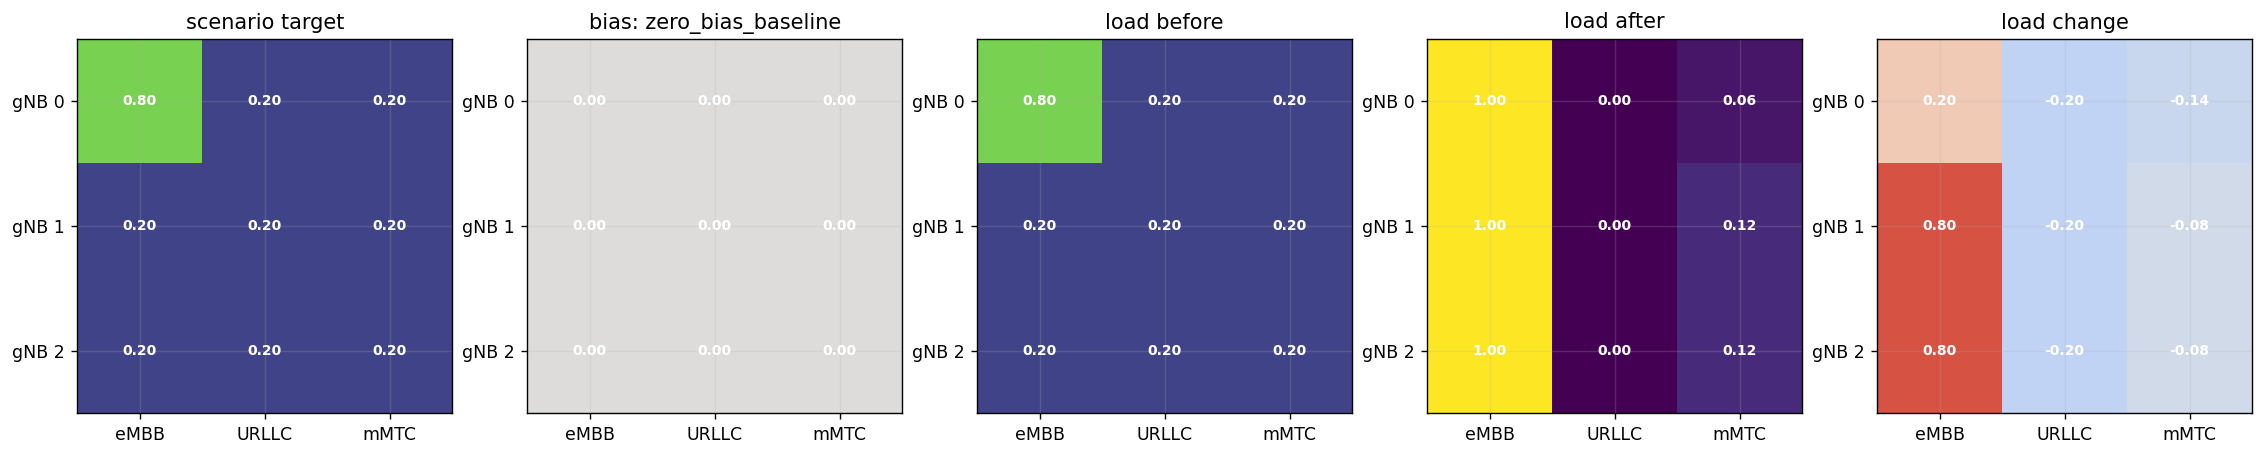

zero_bias_baseline


,eMBB,URLLC,mMTC
gNB 0,3.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,1.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,1.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,3.000000,2.000000,2.000000


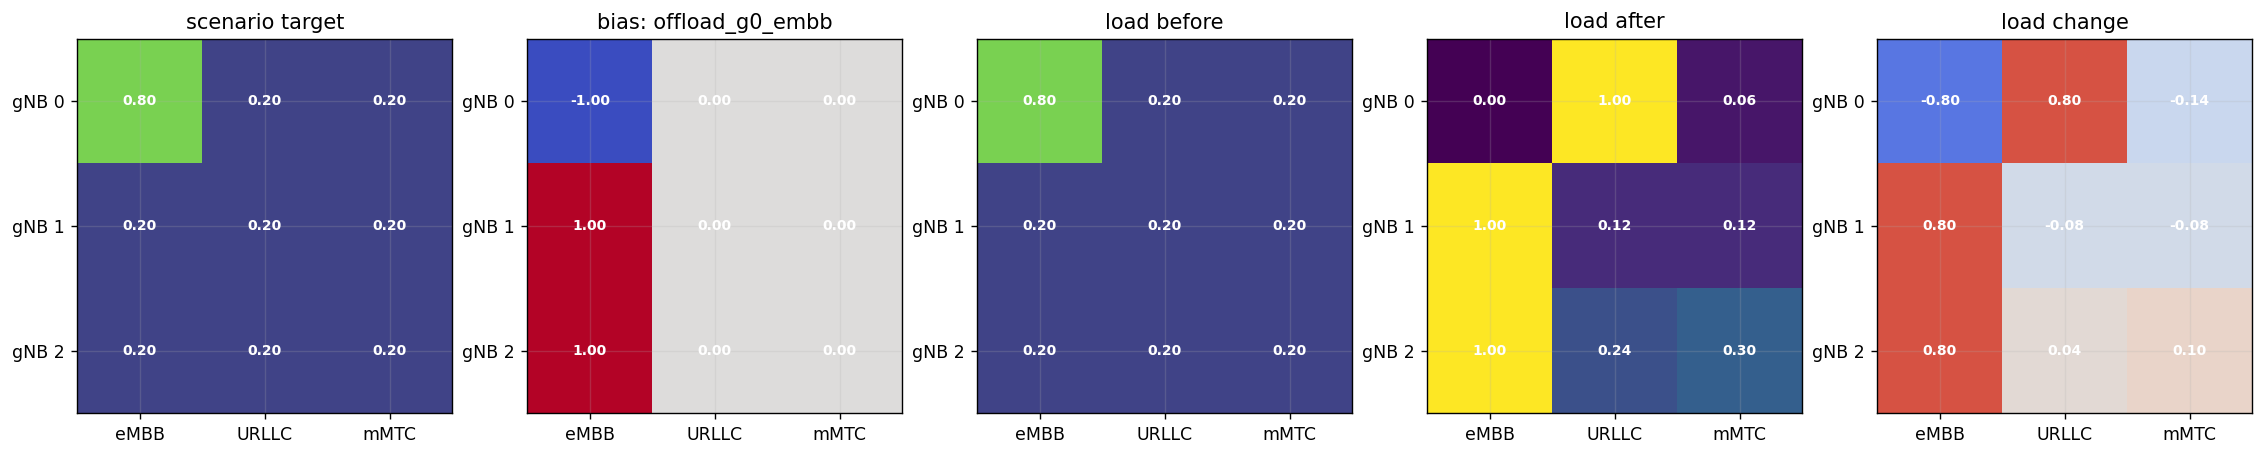

offload_g0_embb


,eMBB,URLLC,mMTC
gNB 0,3.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,1.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,0.000000,1.000000,1.000000
gNB 1,2.000000,2.000000,2.000000
gNB 2,3.000000,2.000000,2.000000


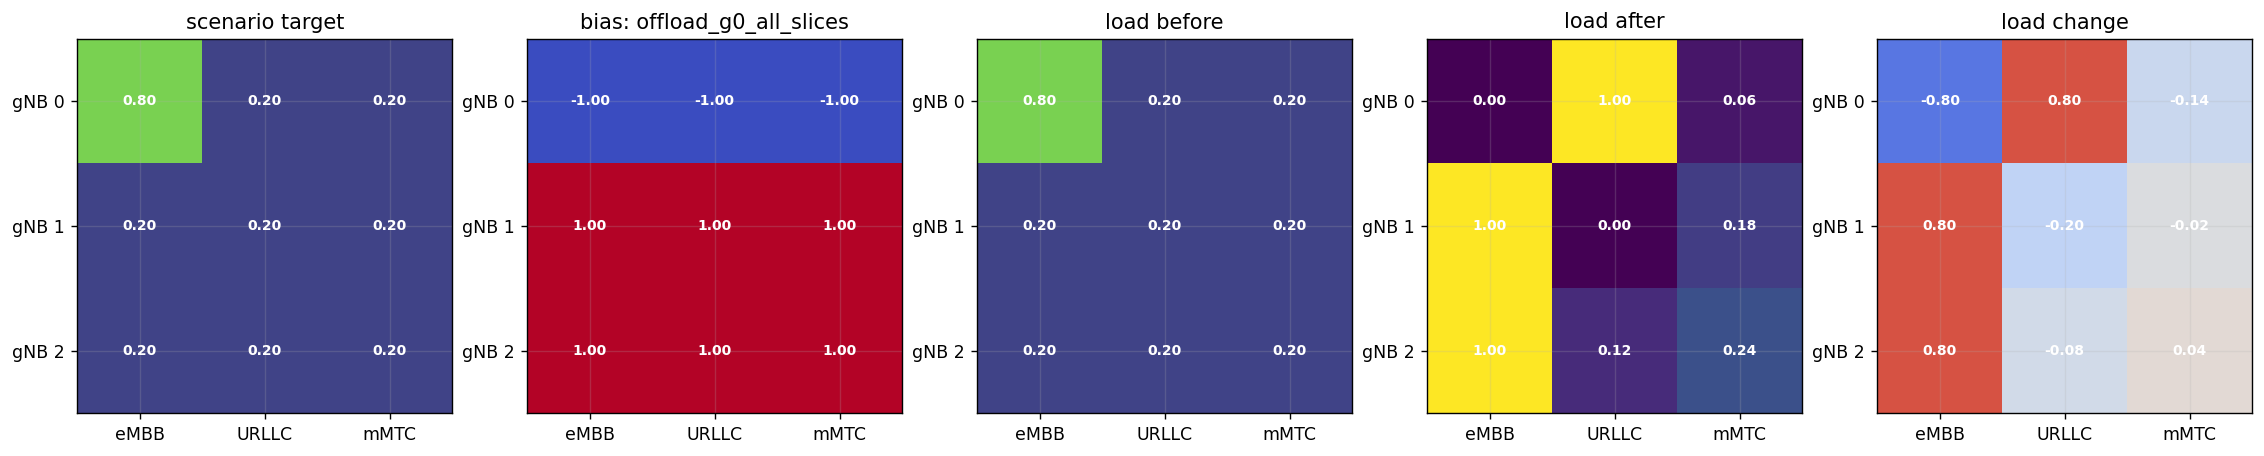

offload_g0_all_slices


,eMBB,URLLC,mMTC
gNB 0,3.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,1.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,0.000000,1.000000,1.000000
gNB 1,2.000000,2.000000,2.000000
gNB 2,3.000000,2.000000,2.000000


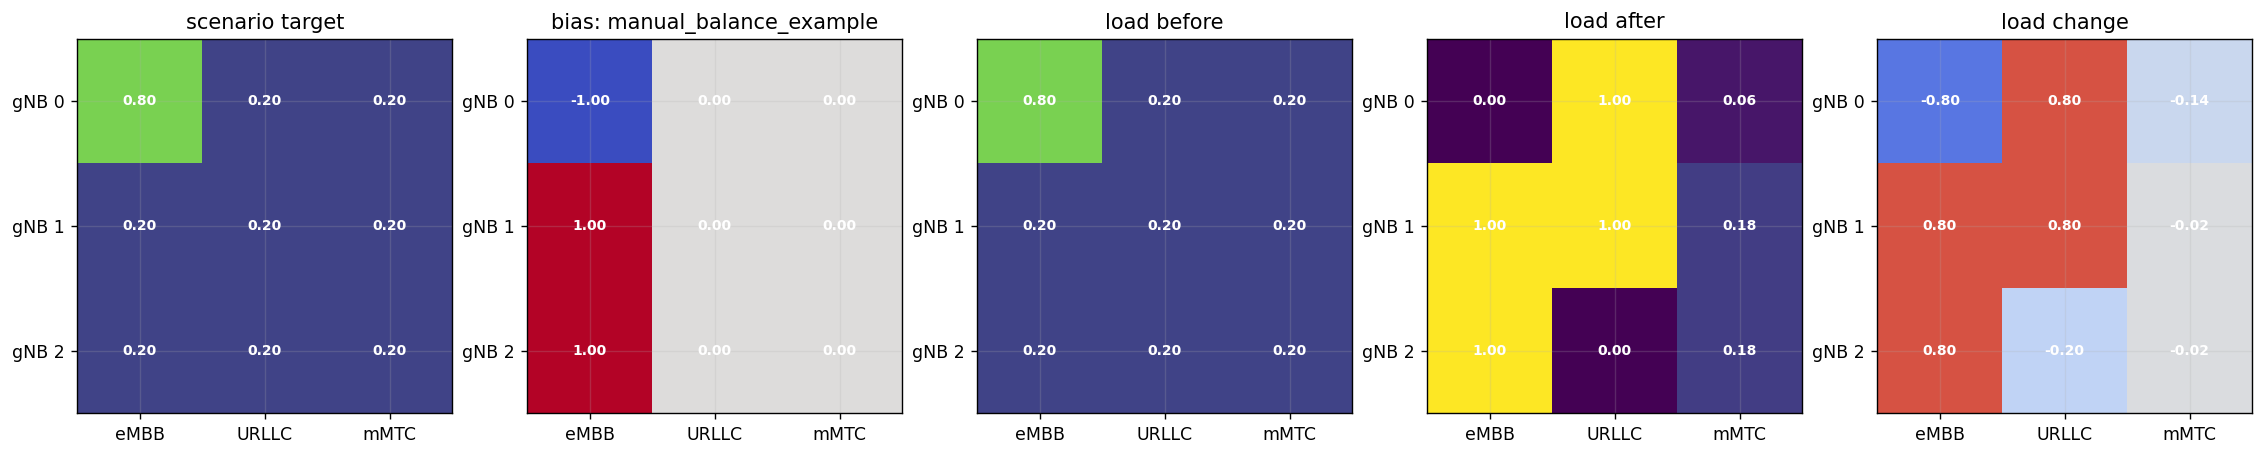

manual_balance_example


,eMBB,URLLC,mMTC
gNB 0,3.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,1.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,0.000000,1.000000,1.000000
gNB 1,2.000000,2.000000,2.000000
gNB 2,3.000000,2.000000,2.000000


In [7]:
for name, result in results.items():
    fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
    heatmap(axes[0], result["target_load"], "scenario target", cmap="viridis", vmin=0, vmax=1)
    heatmap(axes[1], result["bias_matrix"], f"bias: {name}", cmap="coolwarm", vmin=-1, vmax=1)
    heatmap(axes[2], result["initial_load"], "load before", cmap="viridis", vmin=0, vmax=1)
    heatmap(axes[3], result["final_load"], "load after", cmap="viridis", vmin=0, vmax=1)
    heatmap(axes[4], result["final_load"] - result["initial_load"], "load change", cmap="coolwarm", vmin=-1, vmax=1)
    plt.show()

    print(name)
    display(matrix_df(result["initial_ue_count"]).style.set_caption("UE count before"))
    display(matrix_df(result["final_ue_count"]).style.set_caption("UE count after"))

## Error And Handover Curves

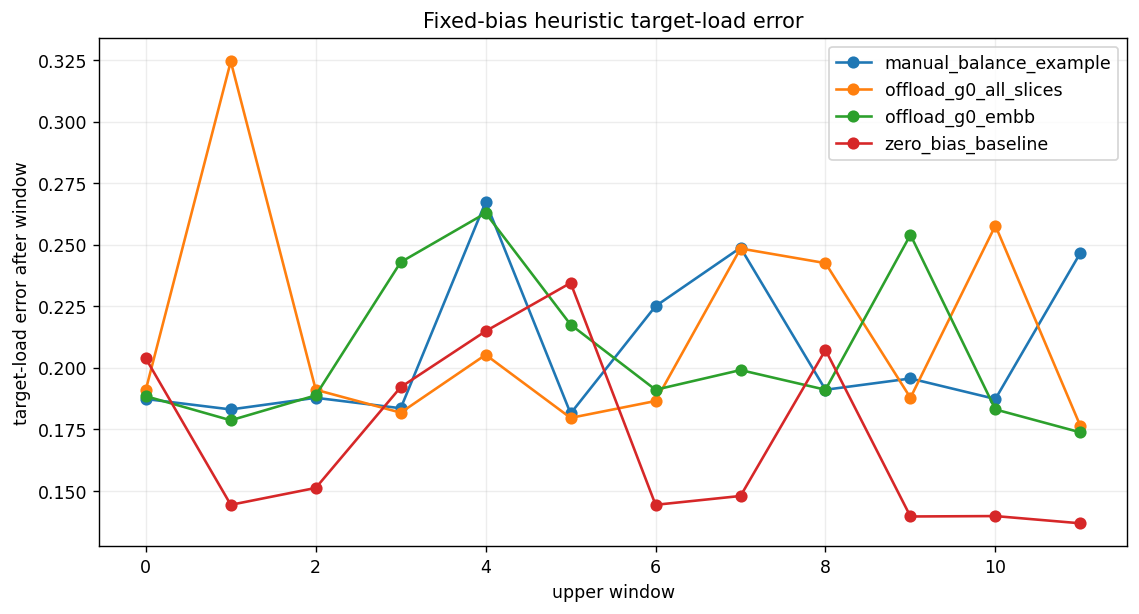

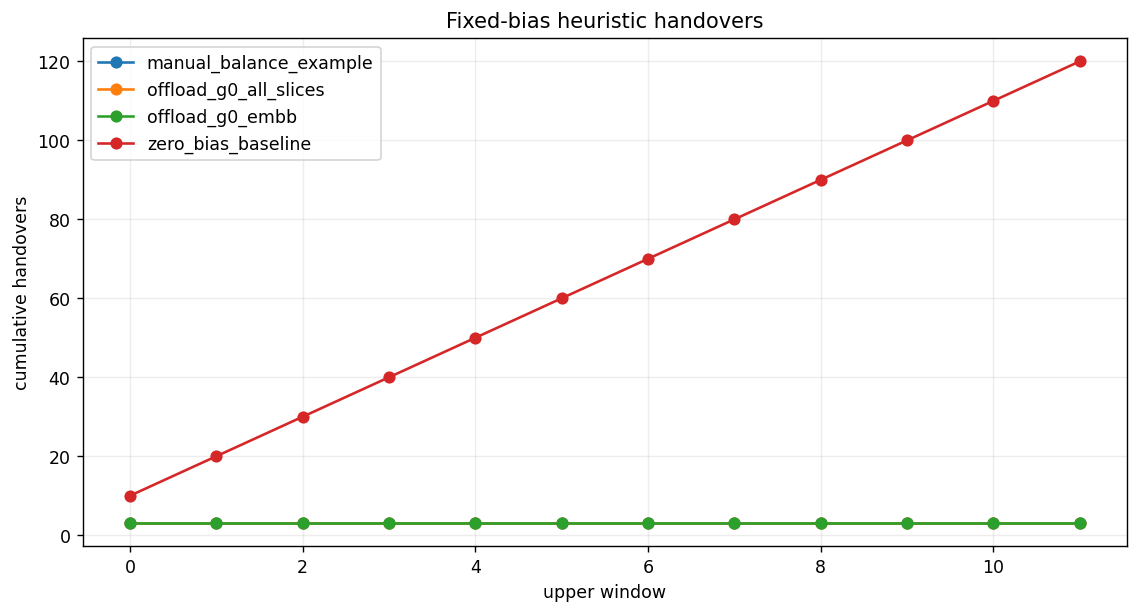

In [8]:
all_history = pd.concat([r["history"] for r in results.values()], ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
for name, rows in all_history.groupby("test"):
    ax.plot(rows["window"], rows["target_error_after"], marker="o", label=name)
ax.set_xlabel("upper window")
ax.set_ylabel("target-load error after window")
ax.set_title("Fixed-bias heuristic target-load error")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
for name, rows in all_history.groupby("test"):
    ax.plot(rows["window"], rows["handover_count"].cumsum(), marker="o", label=name)
ax.set_xlabel("upper window")
ax.set_ylabel("cumulative handovers")
ax.set_title("Fixed-bias heuristic handovers")
ax.legend()
plt.show()

## Paired A/B Test: Offset Effect Above Radio Drift

Because load changes even in radio-only simulation, inspect the offset effect as a paired difference:

`offset_effect = (heuristic_after - heuristic_before) - (radio_only_after - radio_only_before)`

This removes the load drift that happens without heuristic handovers. Also check serving-gNB changes and handover count; those are direct evidence that offsets changed UE attachment.

paired test: offload_g0_embb
radio-only final error: 0.136
heuristic final error: 0.177
heuristic total handovers: 3


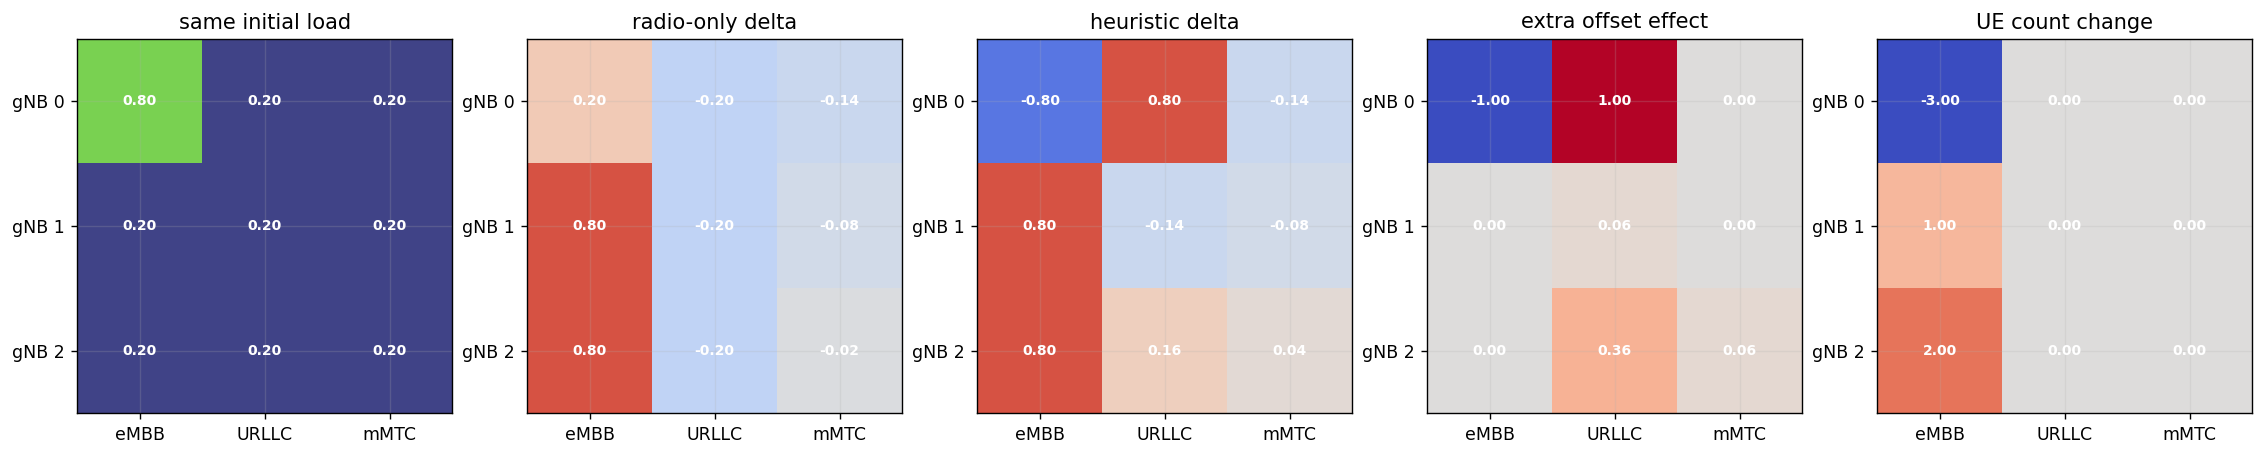

,window,heuristic_error_after,handover_count,heuristic_abs_load_change,radio_error_after,radio_abs_load_change,extra_abs_load_change
0,0,0.277531,3,0.562963,0.144544,0.318519,0.244444
1,1,0.220496,0,0.097643,0.146667,0.114478,-0.016835
2,2,0.191111,0,0.101010,0.135729,0.053872,0.047138
3,3,0.181806,0,0.087542,0.136872,0.074074,0.013468
4,4,0.184581,0,0.087542,0.144055,0.127946,-0.040404
5,5,0.191111,0,0.067340,0.142259,0.074074,-0.006734
6,6,0.177072,0,0.060606,0.144381,0.026936,0.033670
7,7,0.263491,0,0.185185,0.243371,0.265993,-0.080808
8,8,0.191111,0,0.245791,0.139973,0.245791,0.000000
9,9,0.192254,0,0.047138,0.140626,0.033670,0.013468


In [9]:
PAIR_TEST_NAME = "offload_g0_embb"
PAIR_SEED = 7

paired_radio = radio_only_rollout(seed=PAIR_SEED, windows=N_WINDOWS)
paired_heur = rollout_fixed_bias(PAIR_TEST_NAME, BIAS_MATRICES[PAIR_TEST_NAME], seed=PAIR_SEED)

radio_delta = paired_radio["final_load"] - paired_radio["initial_load"]
heur_delta = paired_heur["final_load"] - paired_heur["initial_load"]
offset_effect = heur_delta - radio_delta

print(f"paired test: {PAIR_TEST_NAME}")
print(f"radio-only final error: {paired_radio['history']['target_error_after'].iloc[-1]:.3f}")
print(f"heuristic final error: {paired_heur['history']['target_error_after'].iloc[-1]:.3f}")
print(f"heuristic total handovers: {int(paired_heur['history']['handover_count'].sum())}")

fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
heatmap(axes[0], paired_radio["initial_load"], "same initial load", cmap="viridis", vmin=0, vmax=1)
heatmap(axes[1], radio_delta, "radio-only delta", cmap="coolwarm", vmin=-1, vmax=1)
heatmap(axes[2], heur_delta, "heuristic delta", cmap="coolwarm", vmin=-1, vmax=1)
heatmap(axes[3], offset_effect, "extra offset effect", cmap="coolwarm", vmin=-1, vmax=1)
heatmap(axes[4], paired_heur["final_ue_count"] - paired_heur["initial_ue_count"], "UE count change", cmap="coolwarm", vmin=-3, vmax=3)
plt.show()

paired_compare = paired_heur["history"][["window", "target_error_after", "handover_count", "mean_abs_load_change"]].copy()
paired_compare = paired_compare.rename(columns={
    "target_error_after": "heuristic_error_after",
    "mean_abs_load_change": "heuristic_abs_load_change",
})
paired_compare["radio_error_after"] = paired_radio["history"]["target_error_after"].to_numpy()[:len(paired_compare)]
paired_compare["radio_abs_load_change"] = paired_radio["history"]["mean_abs_load_change"].to_numpy()[:len(paired_compare)]
paired_compare["extra_abs_load_change"] = paired_compare["heuristic_abs_load_change"] - paired_compare["radio_abs_load_change"]
display(paired_compare)

## Why Offload Can Still Show Load 1.0

The load plotted here is PRB load: `used_prbs / slice_prb_budget`. It is not UE count. After offload, the remaining or moved eMBB UEs may still have enough queued traffic to consume all available eMBB PRBs, so the load can stay at `1.0` even though serving attachment changed.

In [10]:
def prb_budget_matrix(env):
    return np.asarray([[env.base_env.get_slice_prb_budget(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)

def prb_used_matrix(env):
    return np.asarray([[env.base_env.get_slice_used_prbs(g, s) for s in SLICE_TYPES] for g in GNB_IDS], dtype=float)

def ue_detail_table(env):
    rows = []
    for ue in env.base_env.get_all_ues():
        rows.append({
            "ue_id": int(ue.id),
            "slice": str(getattr(ue, "slice_type", "eMBB")),
            "serving_gnb": int(ue.serving_gnb) if ue.serving_gnb is not None else -1,
            "prbs": int(getattr(ue, "prbs", 0)),
            "queue": float(getattr(ue, "queue", 0.0)),
            "x": float(ue.x),
            "y": float(ue.y),
        })
    return pd.DataFrame(rows).sort_values(["slice", "serving_gnb", "ue_id"])

diag_env = make_env(seed=PAIR_SEED)
try:
    obs_diag, info_diag = reset_scenario(diag_env)
    before_used = prb_used_matrix(diag_env)
    before_budget = prb_budget_matrix(diag_env)
    before_load = diag_env._load_matrix()
    before_counts = np.asarray(info_diag["ue_count_matrix"], dtype=float)
    before_ues = ue_detail_table(diag_env)

    for _ in range(N_WINDOWS):
        obs_diag, reward_diag, terminated_diag, truncated_diag, info_diag = diag_env.step(BIAS_MATRICES[PAIR_TEST_NAME].reshape(-1))
        if terminated_diag or truncated_diag:
            break

    after_used = prb_used_matrix(diag_env)
    after_budget = prb_budget_matrix(diag_env)
    after_load = diag_env._load_matrix()
    after_counts = np.asarray(info_diag["ue_count_matrix"], dtype=float)
    after_ues = ue_detail_table(diag_env)
finally:
    diag_env.close()

print(f"Diagnostic test: {PAIR_TEST_NAME}")
display(matrix_df(before_counts).style.set_caption("UE count before"))
display(matrix_df(after_counts).style.set_caption("UE count after"))
display(matrix_df(before_used).style.set_caption("Used PRBs before"))
display(matrix_df(after_used).style.set_caption("Used PRBs after"))
display(matrix_df(before_budget).style.set_caption("PRB budget"))
display(matrix_df(before_load).style.set_caption("Load before = used/budget"))
display(matrix_df(after_load).style.set_caption("Load after = used/budget"))

print("eMBB UEs before")
display(before_ues[before_ues["slice"] == "eMBB"])
print("eMBB UEs after")
display(after_ues[after_ues["slice"] == "eMBB"])

Diagnostic test: offload_g0_embb


,eMBB,URLLC,mMTC
gNB 0,3.000000,1.000000,1.000000
gNB 1,1.000000,2.000000,2.000000
gNB 2,1.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,0.000000,1.000000,1.000000
gNB 1,2.000000,2.000000,2.000000
gNB 2,3.000000,2.000000,2.000000


,eMBB,URLLC,mMTC
gNB 0,16.000000,3.000000,1.000000
gNB 1,4.000000,3.000000,1.000000
gNB 2,4.000000,3.000000,1.000000


,eMBB,URLLC,mMTC
gNB 0,0.000000,98.000000,2.000000
gNB 1,80.000000,16.000000,4.000000
gNB 2,48.000000,46.000000,6.000000


...

,eMBB,URLLC,mMTC
gNB 0,0.000000,1.000000,0.060606
gNB 1,1.000000,0.484848,0.121212
gNB 2,1.000000,1.000000,0.181818


eMBB UEs before


,ue_id,slice,serving_gnb,prbs,queue,x,y
0,0,eMBB,0,6,36000.0,185.610222,197.178408
1,1,eMBB,0,5,30000.0,183.818972,181.830716
2,2,eMBB,0,5,30000.0,234.982021,-25.419548
5,5,eMBB,1,4,24000.0,611.064189,-45.692295
10,10,eMBB,2,4,24000.0,93.328087,319.102452


eMBB UEs after


,ue_id,slice,serving_gnb,prbs,queue,x,y
2,2,eMBB,1,64,12000.0,234.982021,-25.419548
5,5,eMBB,1,16,0.0,611.064189,-45.692295
0,0,eMBB,2,24,57656.0,185.610222,197.178408
1,1,eMBB,2,0,21636.0,183.818972,181.830716
10,10,eMBB,2,24,0.0,93.328087,319.102452


## Inspect A3 Offsets For One Test

Change `TEST_NAME` to inspect another fixed-bias matrix.

In [11]:
TEST_NAME = "offload_g0_embb"
offsets = results[TEST_NAME]["offsets"]
display(offsets.head(36))

offset_summary = offsets.groupby(["window", "slice"])["applied_offset_db"].agg(["min", "mean", "max"]).reset_index()
display(offset_summary.head(20))

,test,window,from_gnb,to_gnb,slice,bias,serving_load,neighbor_load,proto_offset_db,applied_offset_db
0,offload_g0_embb,0,0,1,URLLC,0.0,0.200000,0.200000,0.093333,0.0
1,offload_g0_embb,0,0,2,URLLC,0.0,0.200000,0.200000,0.093333,0.0
2,offload_g0_embb,0,0,1,eMBB,-1.0,0.800000,0.200000,-5.473333,-6.0
3,offload_g0_embb,0,0,2,eMBB,-1.0,0.800000,0.200000,-5.473333,-6.0
4,offload_g0_embb,0,0,1,mMTC,0.0,0.200000,0.200000,0.093333,0.0
5,offload_g0_embb,0,0,2,mMTC,0.0,0.200000,0.200000,0.093333,0.0
6,offload_g0_embb,0,1,0,URLLC,0.0,0.200000,0.200000,-0.373333,0.0
7,offload_g0_embb,0,1,2,URLLC,0.0,0.200000,0.200000,0.093333,0.0
8,offload_g0_embb,0,1,0,eMBB,1.0,0.200000,0.800000,6.000000,6.0
9,offload_g0_embb,0,1,2,eMBB,1.0,0.200000,0.200000,3.826667,4.0


,window,slice,min,mean,max
0,0,URLLC,0.0,0.000000,0.0
1,0,eMBB,-6.0,1.333333,6.0
2,0,mMTC,0.0,0.000000,0.0
3,1,URLLC,-4.0,0.333333,4.0
4,1,eMBB,0.0,3.666667,6.0
5,1,mMTC,-2.0,0.000000,2.0
6,2,URLLC,-4.0,-0.333333,4.0
7,2,eMBB,0.0,3.666667,6.0
8,2,mMTC,-2.0,-0.333333,0.0
9,3,URLLC,-4.0,0.000000,4.0


## Topology Before And After For One Test

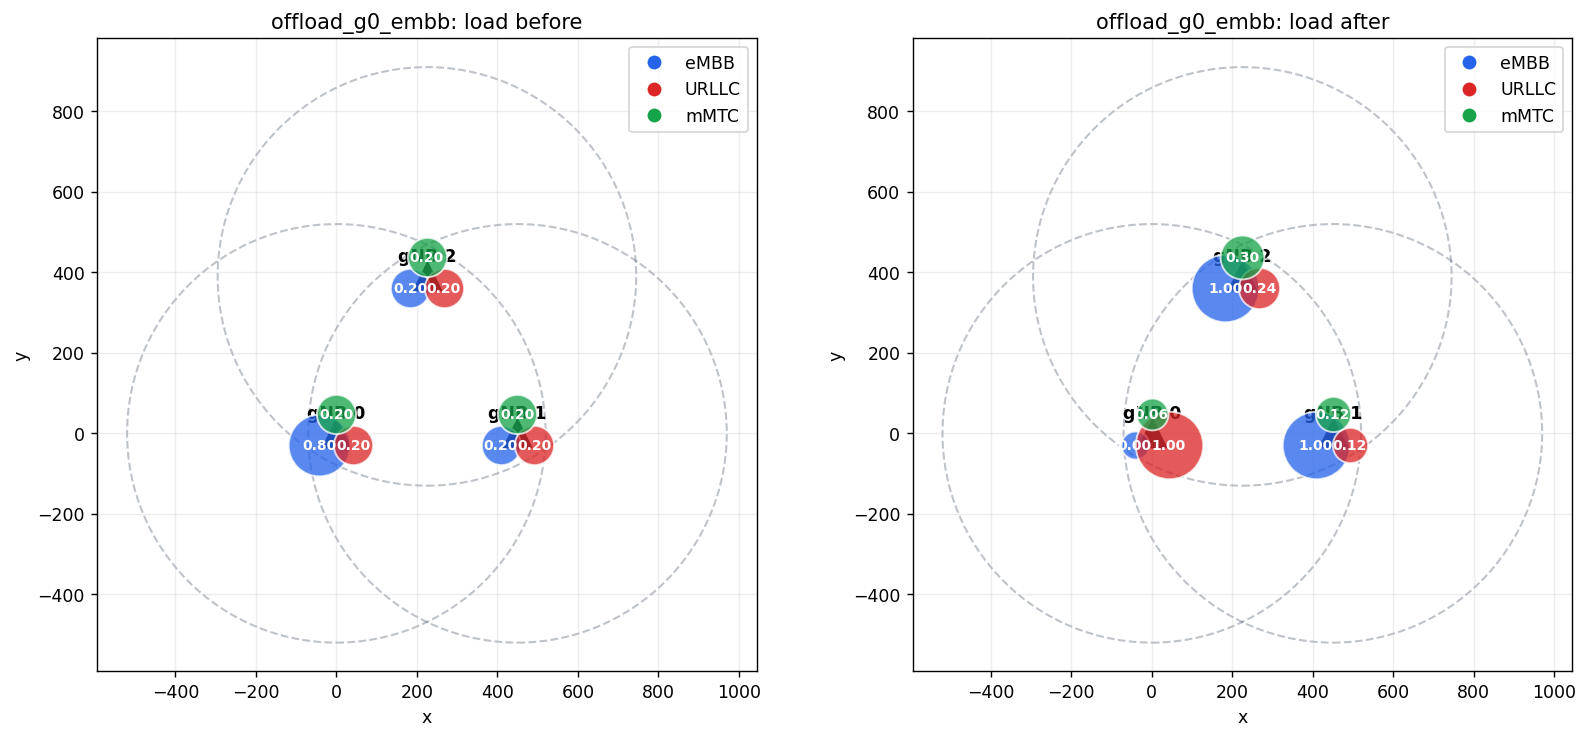

,test,ue_id,slice,serving_gnb,x,y
3,offload_g0_embb,3,URLLC,0,69.452722,-2.276236
4,offload_g0_embb,4,mMTC,0,-163.046970,99.850305
6,offload_g0_embb,6,URLLC,1,434.063208,-122.082345
7,offload_g0_embb,7,URLLC,1,298.349400,113.787279
2,offload_g0_embb,2,eMBB,1,234.982021,-25.419548
5,offload_g0_embb,5,eMBB,1,611.064189,-45.692295
8,offload_g0_embb,8,mMTC,1,379.148912,82.401876
9,offload_g0_embb,9,mMTC,1,375.160173,11.711899
11,offload_g0_embb,11,URLLC,2,54.095301,352.735589
12,offload_g0_embb,12,URLLC,2,332.870147,242.119275


In [12]:
result = results[TEST_NAME]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), constrained_layout=True)
draw_topology_load(axes[0], result["initial_load"], f"{TEST_NAME}: load before")
draw_topology_load(axes[1], result["final_load"], f"{TEST_NAME}: load after")
plt.show()

display(result["ues"].sort_values(["serving_gnb", "slice", "ue_id"]))